In [1]:
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [2]:
df = pd.read_excel("aerial_distance_moscow_vs_gdp_military_spend.xlsx")

In [3]:
X = df[["aerial_distance_moscow"]]

# Target
y = df["Average"]

In [4]:
# We create and fit the linear regression model.

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [5]:
# This allows the ability to make predictions for imagined
# NATO member distances.

y_pred = model.predict(X)

In [6]:
print("Intercept:", model.intercept_)
print(f"Slope: {model.coef_[0]:.10f}")
print("R-squared:", r2_score(y, y_pred))
print("RMSE:", mean_squared_error(y, y_pred) ** 0.5)

# Pearson Correlation Coefficient
r = df["aerial_distance_moscow"].corr(df["Average"])

print("Pearson Correlation Coefficient:", r)

Intercept: 0.029929024243204202
Slope: -0.0000056010
R-squared: 0.35649366954667083
RMSE: 0.005472988026167761
Pearson Correlation Coefficient: -0.5970709083071045


Average Yearly Military Expenditure (% of GDP) = Intercept - Slope * aerial_distance_moscow

>For every single kilometer that a European NATO member gets further from Moscow, we see a 0.00056% decrease in Average Yearly Military Expenditure (% of GDP).

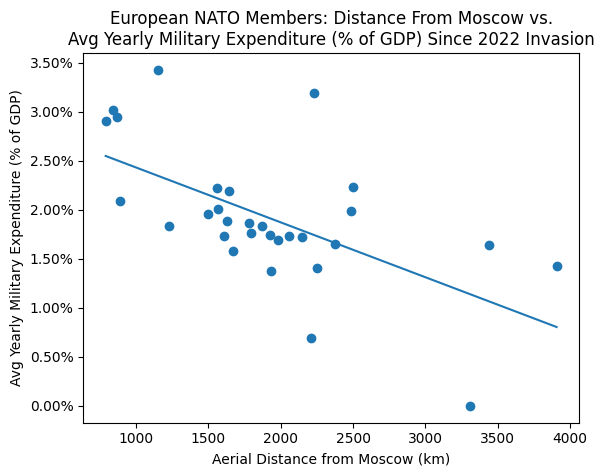

In [7]:
# Plotting the Linear Regression Model

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Aerial Distance from Moscow (km)")
plt.ylabel("Avg Yearly Military Expenditure (% of GDP)")
plt.title("European NATO Members: Distance From Moscow vs.\n"
          "Avg Yearly Military Expenditure (% of GDP) Since 2022 Invasion")

# We have to make the y-axis a percentage.
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.show()

In [8]:
# We'll actually try making a prediction based on 1700 km from Moscow for
# an imaginary NATO member.

imagine_distance = pd.DataFrame({
    "aerial_distance_moscow": [1600]
})

prediction = model.predict(imagine_distance)

print(prediction)

[0.02096744]
